In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('diabetic_data.csv')

# First look
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(101766, 50)
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No        

In [13]:
# Missing value analysis
missing = df.replace('?', pd.NA).isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Show only columns that actually have missing values
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

                   Missing Count  Missing %
weight                     98569      96.86
max_glu_serum              96420      94.75
A1Cresult                  84748      83.28
medical_specialty          49949      49.08
payer_code                 40256      39.56
race                        2273       2.23
diag_3                      1423       1.40
diag_2                       358       0.35
diag_1                        21       0.02


In [14]:
# Drop columns with too many missing values
cols_to_drop = ['weight', 'max_glu_serum', 'A1Cresult', 
                'medical_specialty', 'payer_code']
df.drop(columns=cols_to_drop, inplace=True)

# Replace '?' with NaN
df.replace('?', pd.NA, inplace=True)

# Drop rows with missing values in these columns
cols_to_drop_rows = ['race', 'diag_1', 'diag_2', 'diag_3']
df.dropna(subset=cols_to_drop_rows, inplace=True)

# Reset index after dropping rows
df.reset_index(drop=True, inplace=True)

# Confirm
print("Final cleaned shape:", df.shape)
print("\nAny missing values left?")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Double check no '?' remaining
print("\nAny '?' remaining?")
print((df == '?').sum()[(df == '?').sum() > 0])

Final cleaned shape: (98053, 45)

Any missing values left?
Series([], dtype: int64)

Any '?' remaining?
Series([], dtype: int64)


In [16]:
# Look at the target variable distribution
print(df['readmitted'].value_counts())
print("\nPercentage:")
print((df['readmitted'].value_counts(normalize=True) * 100).round(2))

readmitted
NO     52338
>30    34649
<30    11066
Name: count, dtype: int64

Percentage:
readmitted
NO     53.38
>30    35.34
<30    11.29
Name: proportion, dtype: float64


In [17]:
# Create binary target - 1 if readmitted within 30 days, 0 otherwise
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)

print(df['readmitted_30'].value_counts())
print("\nReadmission rate:", round(df['readmitted_30'].mean() * 100, 2), "%")

readmitted_30
0    86987
1    11066
Name: count, dtype: int64

Readmission rate: 11.29 %


/var/folders/hp/vhxv6c0n2mjfq0psxp51ndg00000gn/T/ipykernel_4320/3071172143.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_readmission, x='age', y='readmission_rate', palette='Blues_d')


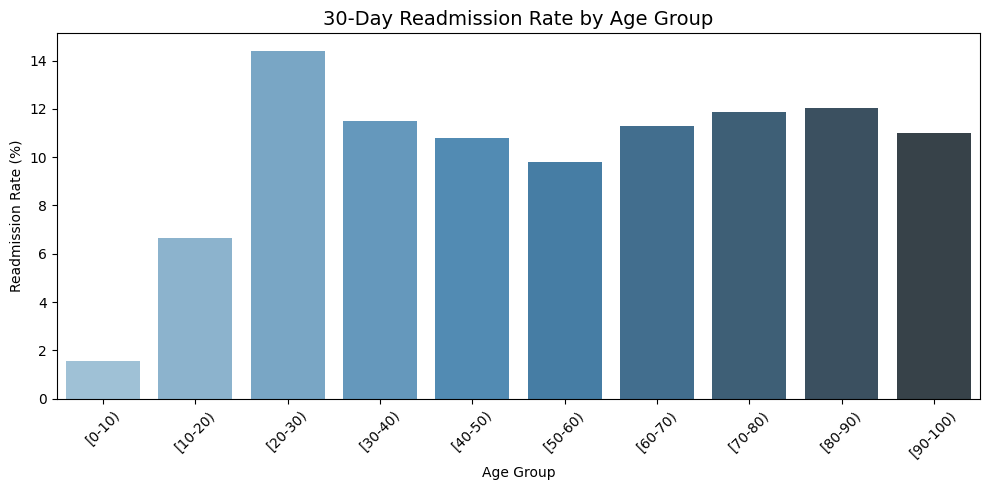

        age  readmission_rate
0    [0-10)          1.538462
1   [10-20)          6.652361
2   [20-30)         14.411367
3   [30-40)         11.499436
4   [40-50)         10.793308
5   [50-60)          9.810146
6   [60-70)         11.279747
7   [70-80)         11.870703
8   [80-90)         12.046462
9  [90-100)         11.004785


In [18]:
# Readmission rate by age group
age_readmission = df.groupby('age')['readmitted_30'].mean() * 100
age_readmission = age_readmission.reset_index()
age_readmission.columns = ['age', 'readmission_rate']
age_readmission = age_readmission.sort_values('age')

plt.figure(figsize=(10, 5))
sns.barplot(data=age_readmission, x='age', y='readmission_rate', palette='Blues_d')
plt.title('30-Day Readmission Rate by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(age_readmission)

In [19]:
# Check how many patients are in each age group
age_counts = df.groupby('age').agg(
    total_patients=('readmitted_30', 'count'),
    readmitted_30_days=('readmitted_30', 'sum'),
    readmission_rate=('readmitted_30', lambda x: round(x.mean() * 100, 2))
).reset_index()

print(age_counts)

        age  total_patients  readmitted_30_days  readmission_rate
0    [0-10)              65                   1              1.54
1   [10-20)             466                  31              6.65
2   [20-30)            1478                 213             14.41
3   [30-40)            3548                 408             11.50
4   [40-50)            9265                1000             10.79
5   [50-60)           16697                1638              9.81
6   [60-70)           21809                2460             11.28
7   [70-80)           25306                3004             11.87
8   [80-90)           16702                2012             12.05
9  [90-100)            2717                 299             11.00


/var/folders/hp/vhxv6c0n2mjfq0psxp51ndg00000gn/T/ipykernel_4320/3054906017.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=inpatient_readmission, x='number_inpatient', y='readmission_rate', palette='Reds_d')


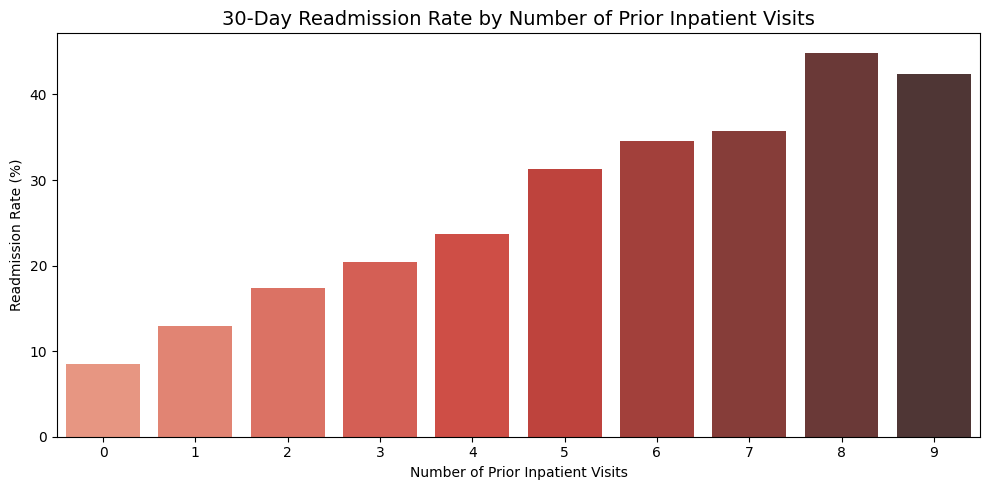

   number_inpatient  total_patients  readmission_rate
0                 0           64634              8.55
1                 1           19067             12.98
2                 2            7421             17.34
3                 3            3346             20.38
4                 4            1597             23.67
5                 5             802             31.30
6                 6             474             34.60
7                 7             266             35.71
8                 8             147             44.90
9                 9             111             42.34


In [20]:
# Readmission rate by number of prior inpatient visits
inpatient_readmission = df.groupby('number_inpatient').agg(
    total_patients=('readmitted_30', 'count'),
    readmission_rate=('readmitted_30', lambda x: round(x.mean() * 100, 2))
).reset_index()

# Filter to groups with at least 100 patients for reliability
inpatient_readmission = inpatient_readmission[inpatient_readmission['total_patients'] >= 100]

plt.figure(figsize=(10, 5))
sns.barplot(data=inpatient_readmission, x='number_inpatient', y='readmission_rate', palette='Reds_d')
plt.title('30-Day Readmission Rate by Number of Prior Inpatient Visits', fontsize=14)
plt.xlabel('Number of Prior Inpatient Visits')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.show()

print(inpatient_readmission)

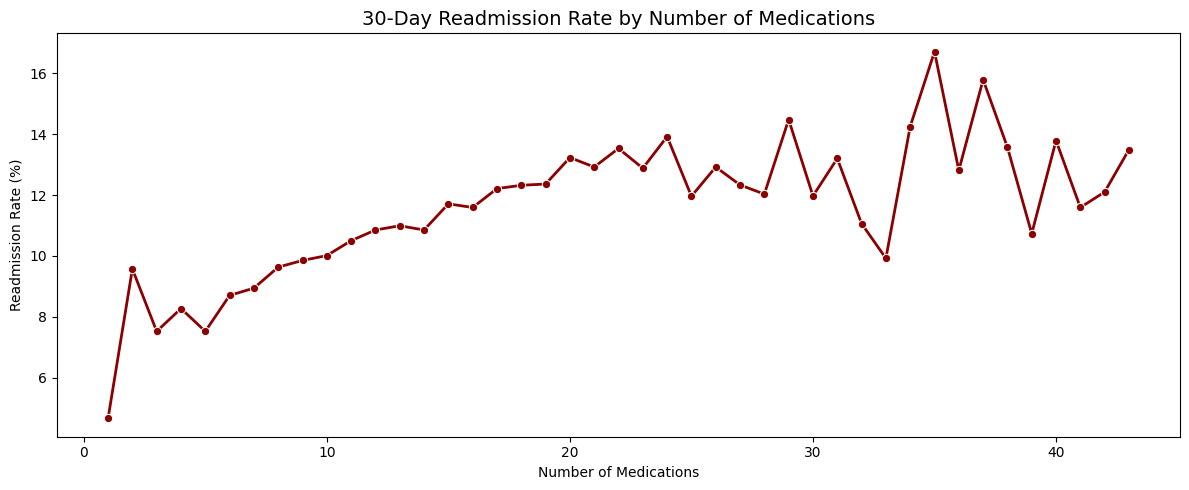

    num_medications  total_patients  readmission_rate
0                 1             236              4.66
1                 2             397              9.57
2                 3             785              7.52
3                 4            1269              8.27
4                 5            1835              7.52
5                 6            2505              8.70
6                 7            3279              8.94
7                 8            4155              9.63
8                 9            4711              9.85
9                10            5167             10.01
10               11            5592             10.50
11               12            5816             10.85
12               13            5885             10.99
13               14            5520             10.85
14               15            5621             11.71
15               16            5271             11.59
16               17            4783             12.21
17               18         

In [21]:
# Readmission rate by number of medications
med_readmission = df.groupby('num_medications').agg(
    total_patients=('readmitted_30', 'count'),
    readmission_rate=('readmitted_30', lambda x: round(x.mean() * 100, 2))
).reset_index()

# Filter to reliable groups
med_readmission = med_readmission[med_readmission['total_patients'] >= 100]

plt.figure(figsize=(12, 5))
sns.lineplot(data=med_readmission, x='num_medications', y='readmission_rate', 
             marker='o', color='darkred', linewidth=2)
plt.title('30-Day Readmission Rate by Number of Medications', fontsize=14)
plt.xlabel('Number of Medications')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.show()

print(med_readmission)

/var/folders/hp/vhxv6c0n2mjfq0psxp51ndg00000gn/T/ipykernel_4320/46396133.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=time_readmission, x='time_in_hospital',


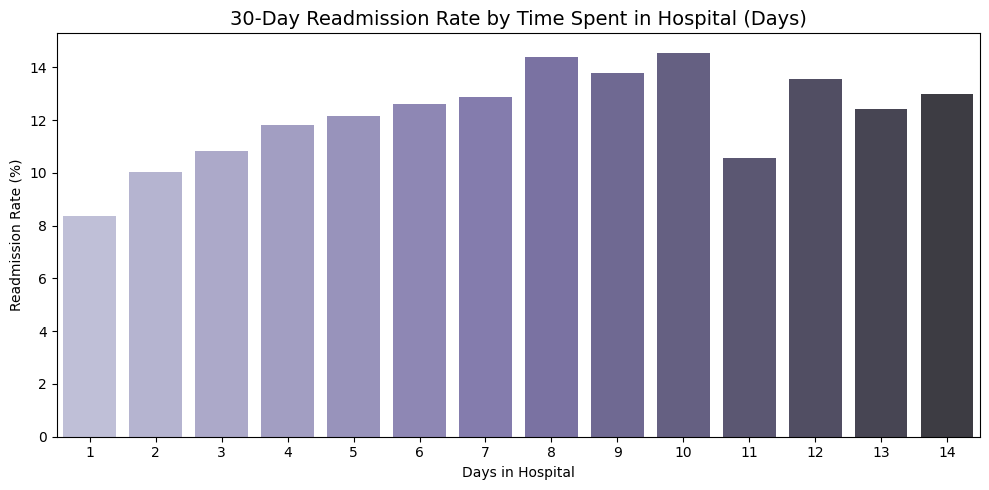

    time_in_hospital  total_patients  readmission_rate
0                  1           13490              8.35
1                  2           16441             10.04
2                  3           17049             10.84
3                  4           13434             11.83
4                  5            9699             12.17
5                  6            7320             12.62
6                  7            5694             12.87
7                  8            4276             14.38
8                  9            2928             13.80
9                 10            2287             14.56
10                11            1809             10.56
11                12            1424             13.55
12                13            1185             12.41
13                14            1017             12.98


In [22]:
# Readmission rate by time in hospital
time_readmission = df.groupby('time_in_hospital').agg(
    total_patients=('readmitted_30', 'count'),
    readmission_rate=('readmitted_30', lambda x: round(x.mean() * 100, 2))
).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=time_readmission, x='time_in_hospital', 
            y='readmission_rate', palette='Purples_d')
plt.title('30-Day Readmission Rate by Time Spent in Hospital (Days)', fontsize=14)
plt.xlabel('Days in Hospital')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.show()

print(time_readmission)

/var/folders/hp/vhxv6c0n2mjfq0psxp51ndg00000gn/T/ipykernel_4320/1978588205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=insulin_readmission, x='insulin', y='readmission_rate',


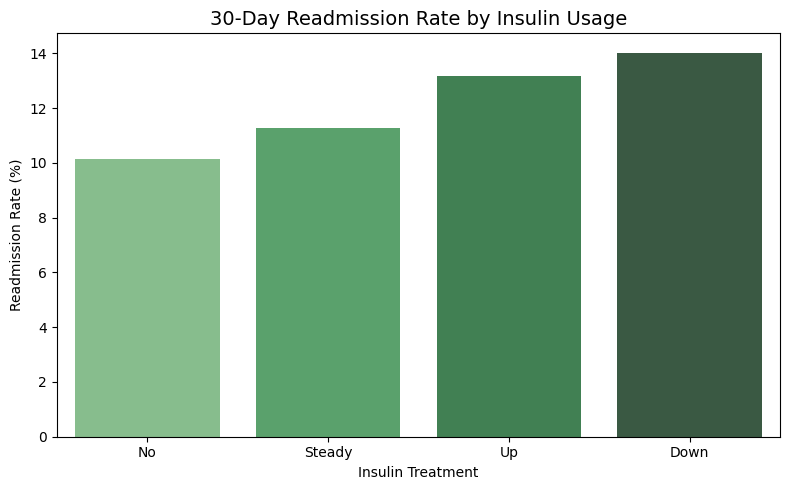

  insulin  total_patients  readmission_rate
0    Down           11843             14.03
1      No           45943             10.14
2  Steady           29368             11.28
3      Up           10899             13.16


In [23]:
# Readmission rate by insulin usage
insulin_readmission = df.groupby('insulin').agg(
    total_patients=('readmitted_30', 'count'),
    readmission_rate=('readmitted_30', lambda x: round(x.mean() * 100, 2))
).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=insulin_readmission, x='insulin', y='readmission_rate', 
            palette='Greens_d',
            order=['No', 'Steady', 'Up', 'Down'])
plt.title('30-Day Readmission Rate by Insulin Usage', fontsize=14)
plt.xlabel('Insulin Treatment')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.show()

print(insulin_readmission)

/var/folders/hp/vhxv6c0n2mjfq0psxp51ndg00000gn/T/ipykernel_4320/982932067.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diag_readmission, x='diag_1_category',


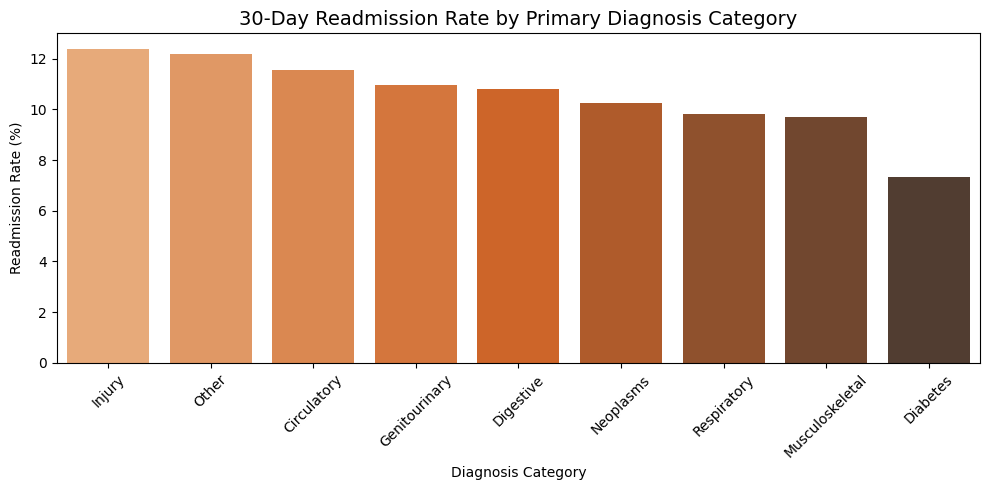

   diag_1_category  total_patients  readmission_rate
4           Injury            6703             12.38
7            Other           25315             12.19
0      Circulatory           29630             11.55
3    Genitourinary            4983             10.98
2        Digestive            9187             10.81
6        Neoplasms            3312             10.24
8      Respiratory           13993              9.83
5  Musculoskeletal            4739              9.69
1         Diabetes             191              7.33


In [24]:
# Simplify diagnosis codes into categories
def categorize_diagnosis(diag):
    try:
        code = float(diag)
        if 390 <= code <= 459 or code == 785:
            return 'Circulatory'
        elif 460 <= code <= 519 or code == 786:
            return 'Respiratory'
        elif 520 <= code <= 579 or code == 787:
            return 'Digestive'
        elif code == 250:
            return 'Diabetes'
        elif 800 <= code <= 999:
            return 'Injury'
        elif 710 <= code <= 739:
            return 'Musculoskeletal'
        elif 580 <= code <= 629 or code == 788:
            return 'Genitourinary'
        elif 140 <= code <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except:
        return 'Other'

df['diag_1_category'] = df['diag_1'].apply(categorize_diagnosis)

# Readmission rate by diagnosis category
diag_readmission = df.groupby('diag_1_category').agg(
    total_patients=('readmitted_30', 'count'),
    readmission_rate=('readmitted_30', lambda x: round(x.mean() * 100, 2))
).reset_index().sort_values('readmission_rate', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=diag_readmission, x='diag_1_category', 
            y='readmission_rate', palette='Oranges_d')
plt.title('30-Day Readmission Rate by Primary Diagnosis Category', fontsize=14)
plt.xlabel('Diagnosis Category')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(diag_readmission)

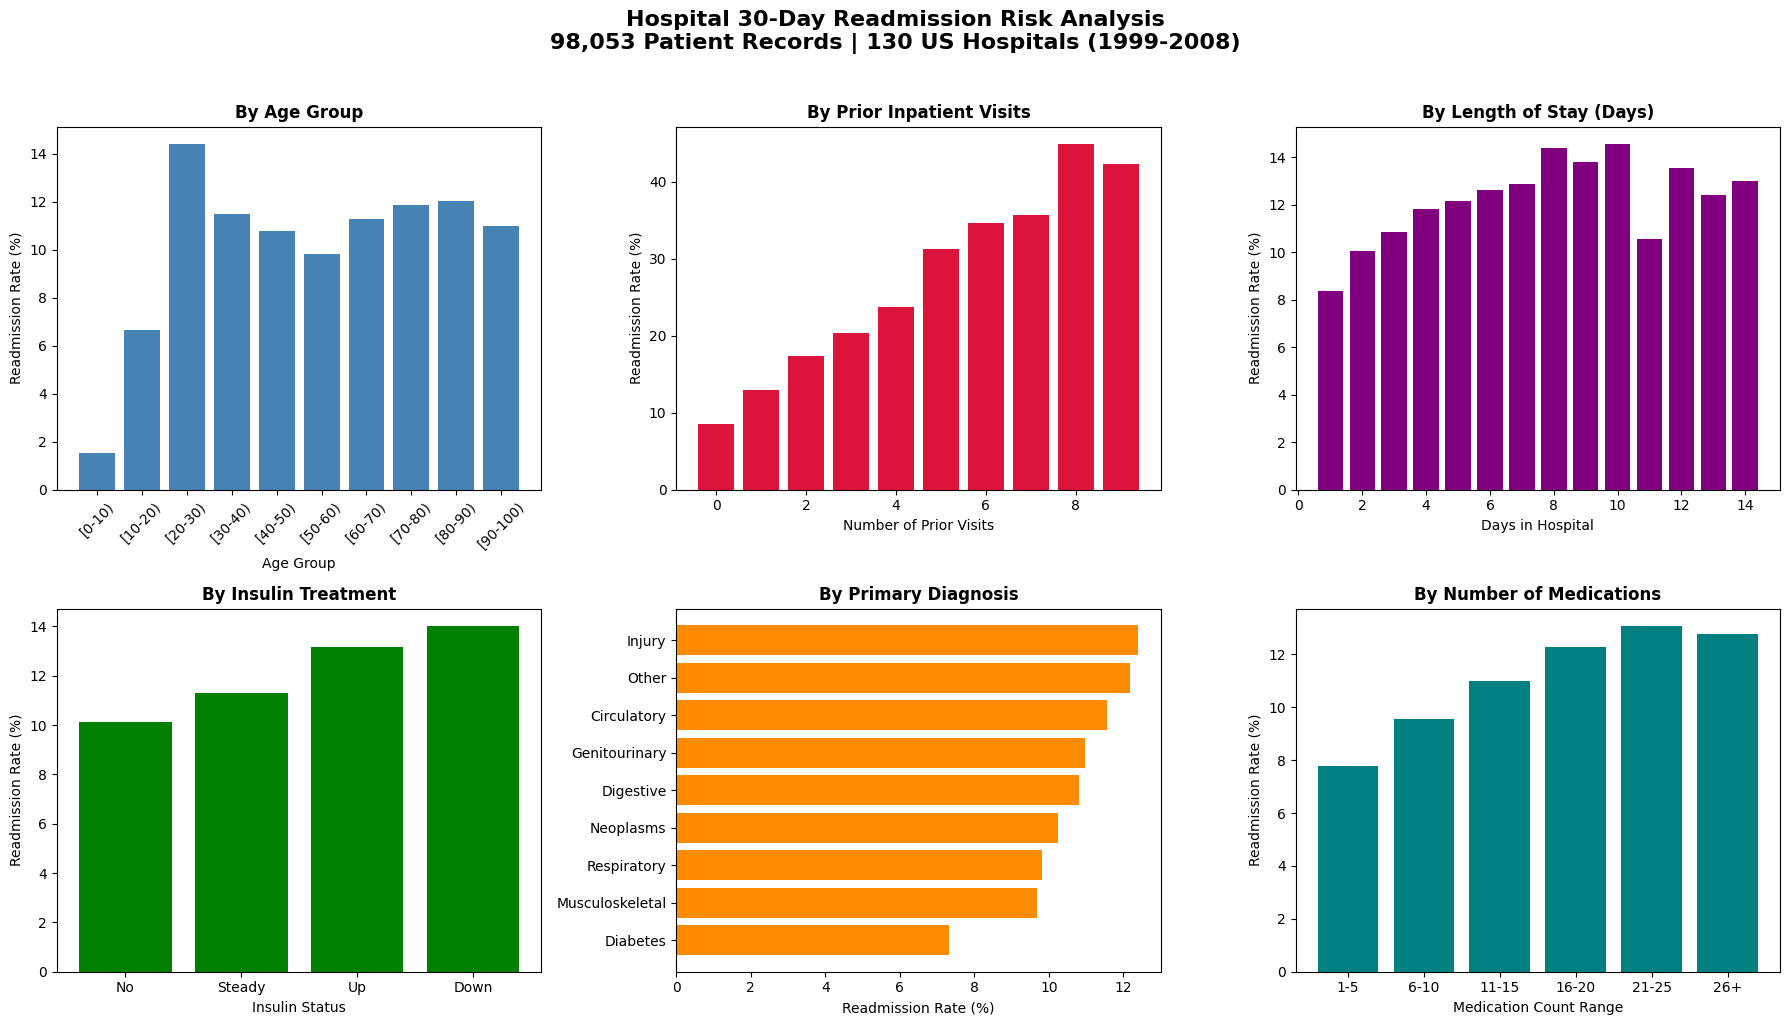

Chart saved as readmission_analysis.png


In [25]:
# Final summary chart - all key findings in one figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Hospital 30-Day Readmission Risk Analysis\n98,053 Patient Records | 130 US Hospitals (1999-2008)', 
             fontsize=16, fontweight='bold', y=1.02)

# 1. Age group
age_data = df.groupby('age')['readmitted_30'].mean() * 100
axes[0,0].bar(age_data.index, age_data.values, color='steelblue')
axes[0,0].set_title('By Age Group', fontweight='bold')
axes[0,0].set_xlabel('Age Group')
axes[0,0].set_ylabel('Readmission Rate (%)')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Prior inpatient visits
inpatient_data = df[df['number_inpatient'] <= 9].groupby('number_inpatient')['readmitted_30'].mean() * 100
axes[0,1].bar(inpatient_data.index, inpatient_data.values, color='crimson')
axes[0,1].set_title('By Prior Inpatient Visits', fontweight='bold')
axes[0,1].set_xlabel('Number of Prior Visits')
axes[0,1].set_ylabel('Readmission Rate (%)')

# 3. Time in hospital
time_data = df.groupby('time_in_hospital')['readmitted_30'].mean() * 100
axes[0,2].bar(time_data.index, time_data.values, color='purple')
axes[0,2].set_title('By Length of Stay (Days)', fontweight='bold')
axes[0,2].set_xlabel('Days in Hospital')
axes[0,2].set_ylabel('Readmission Rate (%)')

# 4. Insulin
insulin_order = ['No', 'Steady', 'Up', 'Down']
insulin_data = df.groupby('insulin')['readmitted_30'].mean() * 100
insulin_data = insulin_data.reindex(insulin_order)
axes[1,0].bar(insulin_data.index, insulin_data.values, color='green')
axes[1,0].set_title('By Insulin Treatment', fontweight='bold')
axes[1,0].set_xlabel('Insulin Status')
axes[1,0].set_ylabel('Readmission Rate (%)')

# 5. Diagnosis category
diag_data = df.groupby('diag_1_category')['readmitted_30'].mean() * 100
diag_data = diag_data.sort_values(ascending=True)
axes[1,1].barh(diag_data.index, diag_data.values, color='darkorange')
axes[1,1].set_title('By Primary Diagnosis', fontweight='bold')
axes[1,1].set_xlabel('Readmission Rate (%)')

# 6. Number of medications (binned)
df['med_bin'] = pd.cut(df['num_medications'], 
                        bins=[0,5,10,15,20,25,45], 
                        labels=['1-5','6-10','11-15','16-20','21-25','26+'])
med_data = df.groupby('med_bin', observed=True)['readmitted_30'].mean() * 100
axes[1,2].bar(med_data.index, med_data.values, color='teal')
axes[1,2].set_title('By Number of Medications', fontweight='bold')
axes[1,2].set_xlabel('Medication Count Range')
axes[1,2].set_ylabel('Readmission Rate (%)')

plt.tight_layout()
plt.savefig('readmission_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as readmission_analysis.png")